In [2]:
import pandas as pd
import numpy as np
from pybdm import BDM
#from pybdm import PartitionCorrelated
from pybdm import PartitionRecursive
from statistics import harmonic_mean

In [3]:
exp_path = "RandomBinarySeriesWithLLMs.csv"
bin_seq_df = pd.read_csv(exp_path)
bin_seq_df

,sequence,chatgpt_4.5-formula,chatgpt_4.5-formula-eval,chatgpt_4.5-formula-correctness,chatgpt_4.5-formula-copy_seq,chatgpt_4.5-formula-ordinal,BDM/CTM-formula,BDM/CTM-formula-2,BDM/CTM-formula-eval,BDM/CTM-formula-correctness,...,o1_preview-formula-eval,o1_preview-formula-correctness,o1_preview-formula-copy_seq,mistral-program,mistral-program-print,mistral-program-correctness,mistral-formula,mistral-formula-copy_seq,mistral-formula-ordinal,mistral-formula-correctness
0,"1,1,0,0,0,1,0,0,0,0,1,0","[""[int(i in [0,1,5,10]) for i in range(12)]"", ...","1,1,0,0,0,1,0,0,0,0,1,0",True,False,True,"""1""","""1"",1,1,0,0,0,1,0,0,0,0,1,0","1,1,0,0,0,1,0,0,0,0,1,0",True,...,"1,1,0,0,0,1,0,0,0,0,1,0",True,False,"print([1,1,0,0,0,1,0,0,0,0,1,0])",True,True,"[1,1,0,0,0,1,0,0,0,0,1,0]",True,False,True
1,"0,0,0,1,0,1,1,0,1,0,1,1","[""[int(i in [3,5,6,8,10,11]) for i in range(12...","0,0,0,1,0,1,1,0,1,0,1,1",True,False,True,"""1""","""1"",0,0,0,1,0,1,1,0,1,0,1,1","0,0,0,1,0,1,1,0,1,0,1,1",True,...,"0,0,0,1,0,1,1,0,1,0,1,1",True,False,"print([0,0,0,1,0,1,1,0,1,0,1,1])",True,True,"[0,0,0,1,0,1,1,0,1,0,1,1]",True,False,True
2,"1,0,0,0,0,1,1,1,1,0,0,1","[""[int(i in [0,5,6,7,8,11]) for i in range(12)...","1,0,0,0,0,1,1,1,1,0,0,1",True,False,True,"""1""","""1"",1,0,0,0,0,1,1,1,1,0,0,1","1,0,0,0,0,1,1,1,1,0,0,1",True,...,"1,0,0,0,0,1,1,1,1,0,0,1",True,False,"print([1,0,0,0,0,1,1,1,1,0,0,1])",True,True,"[1,0,0,0,0,1,1,1,1,0,0,1]",True,False,True
3,"1,1,1,1,1,1,1,1,0,1,0,0","[""[int(i<8 or i==9) for i in range(12)]"", ""[1]...","1,1,1,1,1,1,1,1,0,1,0,0",True,False,True,"""1""","""1"",1,1,1,1,1,1,1,1,0,1,0,0","1,1,1,1,1,1,1,1,0,1,0,0",True,...,"1,1,1,1,1,1,1,1,0,1,0,0",True,False,"print([1,1,1,1,1,1,1,1,0,1,0,0])",True,True,"[1,1,1,1,1,1,1,1,0,1,0,0]",True,False,True
4,"1,0,1,1,0,1,0,1,0,1,0,0","[""[int(i in [0,2,3,5,7,9]) for i in range(12)]...","1,0,1,1,0,1,0,1,0,1,0,0",True,False,True,"""1""","""1"",1,0,1,1,0,1,0,1,0,1,0,0","1,0,1,1,0,1,0,1,0,1,0,0",True,...,"1,0,1,1,0,1,0,1,0,1,0,0",True,False,"print([1,0,1,1,0,1,0,1,0,1,0,0])",True,True,"[1,0,1,1,0,1,0,1,0,1,0,0]",True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,"1,0,1,1,1,1,1,0,1,1,1,0","[""[int(i in [2,4,5,6,9,10,11]) for i in range(...","1,0,1,1,1,1,1,0,1,1,1,0",True,False,True,"""1""","""1"",1,0,1,1,1,1,1,0,1,1,1,0","1,0,1,1,1,1,1,0,1,1,1,0",True,...,"0,1,0,1,0,0,0,0,0,1,1,0",False,False,"print([1,0,1,1,1,1,1,0,1,1,1,0])",True,True,"[1,0,1,1,1,1,1,0,1,1,1,0]",True,False,True
96,"0,1,0,1,0,0,1,1,0,1,0,1","[""[int(i in [2,4,5,6,9,10,11]) for i in range(...","0,1,0,1,0,0,1,1,0,1,0,1",True,False,True,"""1""","""1"",0,1,0,1,0,0,1,1,0,1,0,1","0,1,0,1,0,0,1,1,0,1,0,1",True,...,"0,1,0,0,0,1,1,0,1,1,0,0",False,False,"print([0,1,0,1,0,0,1,1,0,1,0,1])",True,True,"[0,1,0,1,0,0,1,1,0,1,0,1]",True,False,True
97,"0,0,0,1,0,1,0,0,1,1,1,1","[""[int(i in [2,4,5,6,9,10,11]) for i in range(...","0,0,0,1,0,1,0,0,1,1,1,1",True,False,True,"""1""","""1"",0,0,0,1,0,1,0,0,1,1,1,1","0,0,0,1,0,1,0,0,1,1,1,1",True,...,"0,0,1,0,0,1,0,1,1,1,1,1",False,False,"print([0,0,0,1,0,1,0,0,1,1,1,1])",True,True,"[0,0,0,1,0,1,0,0,1,1,1,1]",True,False,True
98,"1,1,1,0,0,0,1,1,1,1,1,1","[""[int(i in [2,4,5,6,9,10,11]) for i in range(...","1,1,1,0,0,0,1,1,1,1,1,1",True,False,True,"""1""","""1"",1,1,1,0,0,0,1,1,1,1,1,1","1,1,1,0,0,0,1,1,1,1,1,1",True,...,"1,0,1,1,0,1,1,1,0,1,1,1",False,False,"print([1,1,1,0,0,0,1,1,1,1,1,1])",True,True,"[1,1,1,0,0,0,1,1,1,1,1,1]",True,False,True


In [4]:
models = ['gpt_4o', 'claude_3.5', 'gpt_4o_mini', 'cursor_small', 'gemini', 'meta', 
          'o1_mini', 'o1_preview', 'mistral', 'qwen', 'grok_3', 'deepseek', 'claude_3.7', 'chatgpt_4.5']#,'BDM/CTM']

In [5]:
def ascii_to_binary_list(text):
    binary_list = []
    for char in text:
        # Convert each character to its binary representation
        binary_representation = format(ord(char), '08b')
        # Extend the binary_list with the numerical digits of the binary representation
        binary_list.extend([int(bit) for bit in binary_representation])
    return np.array(binary_list).astype(np.int8)

def bdm_compressed(text):
    bdm = BDM(ndim=1,partition=PartitionCorrelated)
    return bdm.bdm(ascii_to_binary_list(text))

In [ ]:
def tst_calc(v1,v2):
    v3 = v2[:3]*np.array([1,0.5,0.25])
    return np.sum(v1[:3]*v3)-v1[-1]

test_vals=[]
dd=3
bdm = BDM(ndim=1,partition=PartitionRecursive)
for mdl in models:#[:-1]:
    sep_df= bin_seq_df[['sequence',f'{mdl}-formula',f'{mdl}-formula-correctness',f'{mdl}-formula-ordinal',f'{mdl}-formula-copy_seq']].copy()
ra    sep_df["bdm_formula"]=[bdm.bdm(ascii_to_binary_list(x)) for x in sep_df[f'{mdl}-formula'].to_numpy()]
    sep_df["bdm_input"]=[bdm.bdm(ascii_to_binary_list(x)) for x in sep_df['sequence'].to_numpy()]
    sep_df["bdm_min"] = [bdm.bdm(seq) for seq in np.array([np.array(x.split(",")).astype(np.int8) for x in sep_df["sequence"].to_numpy()])]
    df_c_n_n = sep_df[sep_df[f"{mdl}-formula-correctness"] & ~sep_df[f"{mdl}-formula-ordinal"] & ~sep_df[f"{mdl}-formula-copy_seq"]]
    df_c_o = sep_df[sep_df[f"{mdl}-formula-correctness"] & sep_df[f"{mdl}-formula-ordinal"]]
    df_c_p = sep_df[sep_df[f"{mdl}-formula-correctness"] & sep_df[f"{mdl}-formula-copy_seq"]]
    df_i = sep_df[~sep_df[f"{mdl}-formula-correctness"]]
    v1=np.array([len(x)/100 for x in [df_c_n_n,df_c_o,df_c_p,df_i]])
    v2 = []
    for x in [df_c_n_n,df_c_o,df_c_p,df_i]:
        datax = (x["bdm_min"]/x["bdm_formula"]).to_numpy()
        if len(datax)>0:
            v2.append(harmonic_mean(datax))
        else:
            v2.append(0)
    v2 = (np.nan_to_num(np.array(v2)))
    tst = tst_calc(v1,v2)
    test_vals.append([mdl]+list(v1)+list(v2[:3])+[tst])

In [7]:
df_ranking = pd.DataFrame(test_vals)
df_ranking.columns = ["Model","p1","p2","p3","p4","r1","r2","r3","tst"]
df_ranking.sort_values(by=['tst'],ascending=False).set_index(["Model"])



,p1,p2,p3,p4,r1,r2,r3,tst
Model,,,,,,,,
qwen,0.00,0.00,1.0,0.00,0.000000,0.000000,0.186810,0.046703
gpt_4o_mini,0.00,0.00,1.0,0.00,0.000000,0.000000,0.141100,0.035275
cursor_small,0.00,0.00,1.0,0.00,0.000000,0.000000,0.141100,0.035275
gemini,0.00,0.00,1.0,0.00,0.000000,0.000000,0.141100,0.035275
mistral,0.00,0.00,1.0,0.00,0.000000,0.000000,0.115663,0.028916
deepseek,0.00,0.00,1.0,0.00,0.000000,0.000000,0.115663,0.028916
chatgpt_4.5,0.00,1.00,0.0,0.00,0.000000,0.030567,0.000000,0.015284
claude_3.7,0.00,0.81,0.0,0.19,0.000000,0.032464,0.000000,-0.176852
o1_mini,0.00,0.64,0.0,0.36,0.000000,0.058448,0.000000,-0.341297


In [8]:
from copy import deepcopy
df_ranking2 = deepcopy(df_ranking)
df_ranking2 #.sort_values(by='tst', ascending=False)


,Model,p1,p2,p3,p4,r1,r2,r3,tst
0,gpt_4o,0.00,0.00,0.0,1.00,0.000000,0.000000,0.000000,-1.000000
1,claude_3.5,0.06,0.14,0.0,0.80,0.061253,0.047818,0.000000,-0.792978
2,gpt_4o_mini,0.00,0.00,1.0,0.00,0.000000,0.000000,0.141100,0.035275
3,cursor_small,0.00,0.00,1.0,0.00,0.000000,0.000000,0.141100,0.035275
4,gemini,0.00,0.00,1.0,0.00,0.000000,0.000000,0.141100,0.035275
5,meta,0.00,0.00,0.0,1.00,0.000000,0.000000,0.000000,-1.000000
6,o1_mini,0.00,0.64,0.0,0.36,0.000000,0.058448,0.000000,-0.341297
7,o1_preview,0.00,0.29,0.0,0.71,0.000000,0.047635,0.000000,-0.703093
8,mistral,0.00,0.00,1.0,0.00,0.000000,0.000000,0.115663,0.028916
9,qwen,0.00,0.00,1.0,0.00,0.000000,0.000000,0.186810,0.046703


In [9]:
# new_row = {'Model': 'BDM/CTM', 'p1': 1, 'p2': 0, 'p3': 0, 'p4': 0, 'r1': 1, 'r2': 0, 'r3': 1, 'tst': 1}
# df_ranking2 = pd.concat([df_ranking2, pd.DataFrame([new_row])], ignore_index=True)
# df_ranking2

In [10]:
df_ranking2 = df_ranking2.sort_values(by='tst', ascending=False)
df_ranking2

,Model,p1,p2,p3,p4,r1,r2,r3,tst
9,qwen,0.00,0.00,1.0,0.00,0.000000,0.000000,0.186810,0.046703
2,gpt_4o_mini,0.00,0.00,1.0,0.00,0.000000,0.000000,0.141100,0.035275
3,cursor_small,0.00,0.00,1.0,0.00,0.000000,0.000000,0.141100,0.035275
4,gemini,0.00,0.00,1.0,0.00,0.000000,0.000000,0.141100,0.035275
8,mistral,0.00,0.00,1.0,0.00,0.000000,0.000000,0.115663,0.028916
11,deepseek,0.00,0.00,1.0,0.00,0.000000,0.000000,0.115663,0.028916
13,chatgpt_4.5,0.00,1.00,0.0,0.00,0.000000,0.030567,0.000000,0.015284
12,claude_3.7,0.00,0.81,0.0,0.19,0.000000,0.032464,0.000000,-0.176852
6,o1_mini,0.00,0.64,0.0,0.36,0.000000,0.058448,0.000000,-0.341297
7,o1_preview,0.00,0.29,0.0,0.71,0.000000,0.047635,0.000000,-0.703093


In [11]:
# Normalize tst values in df_ranking2 to be between 0 and 0.1
df_ranking2['tst'] = (df_ranking2['tst'] - df_ranking2['tst'].min()) / (df_ranking2['tst'].max() - df_ranking2['tst'].min()) * 0.1
df_ranking2


,Model,p1,p2,p3,p4,r1,r2,r3,tst
9,qwen,0.00,0.00,1.0,0.00,0.000000,0.000000,0.186810,0.100000
2,gpt_4o_mini,0.00,0.00,1.0,0.00,0.000000,0.000000,0.141100,0.098908
3,cursor_small,0.00,0.00,1.0,0.00,0.000000,0.000000,0.141100,0.098908
4,gemini,0.00,0.00,1.0,0.00,0.000000,0.000000,0.141100,0.098908
8,mistral,0.00,0.00,1.0,0.00,0.000000,0.000000,0.115663,0.098301
11,deepseek,0.00,0.00,1.0,0.00,0.000000,0.000000,0.115663,0.098301
13,chatgpt_4.5,0.00,1.00,0.0,0.00,0.000000,0.030567,0.000000,0.096998
12,claude_3.7,0.00,0.81,0.0,0.19,0.000000,0.032464,0.000000,0.078642
6,o1_mini,0.00,0.64,0.0,0.36,0.000000,0.058448,0.000000,0.062931
7,o1_preview,0.00,0.29,0.0,0.71,0.000000,0.047635,0.000000,0.028366


In [12]:
new_row = {'Model': 'ASI', 'p1': 1, 'p2': 0, 'p3': 0, 'p4': 0, 'r1': 1, 'r2': 0, 'r3': 1, 'tst': 1}
df_ranking2 = pd.concat([df_ranking2, pd.DataFrame([new_row])], ignore_index=True)

In [13]:
df_ranking2 = df_ranking2.sort_values(by='tst', ascending=False)
df_ranking2

,Model,p1,p2,p3,p4,r1,r2,r3,tst
14,ASI,1.00,0.00,0.0,0.00,1.000000,0.000000,1.000000,1.000000
0,qwen,0.00,0.00,1.0,0.00,0.000000,0.000000,0.186810,0.100000
1,gpt_4o_mini,0.00,0.00,1.0,0.00,0.000000,0.000000,0.141100,0.098908
2,cursor_small,0.00,0.00,1.0,0.00,0.000000,0.000000,0.141100,0.098908
3,gemini,0.00,0.00,1.0,0.00,0.000000,0.000000,0.141100,0.098908
4,mistral,0.00,0.00,1.0,0.00,0.000000,0.000000,0.115663,0.098301
5,deepseek,0.00,0.00,1.0,0.00,0.000000,0.000000,0.115663,0.098301
6,chatgpt_4.5,0.00,1.00,0.0,0.00,0.000000,0.030567,0.000000,0.096998
7,claude_3.7,0.00,0.81,0.0,0.19,0.000000,0.032464,0.000000,0.078642
8,o1_mini,0.00,0.64,0.0,0.36,0.000000,0.058448,0.000000,0.062931


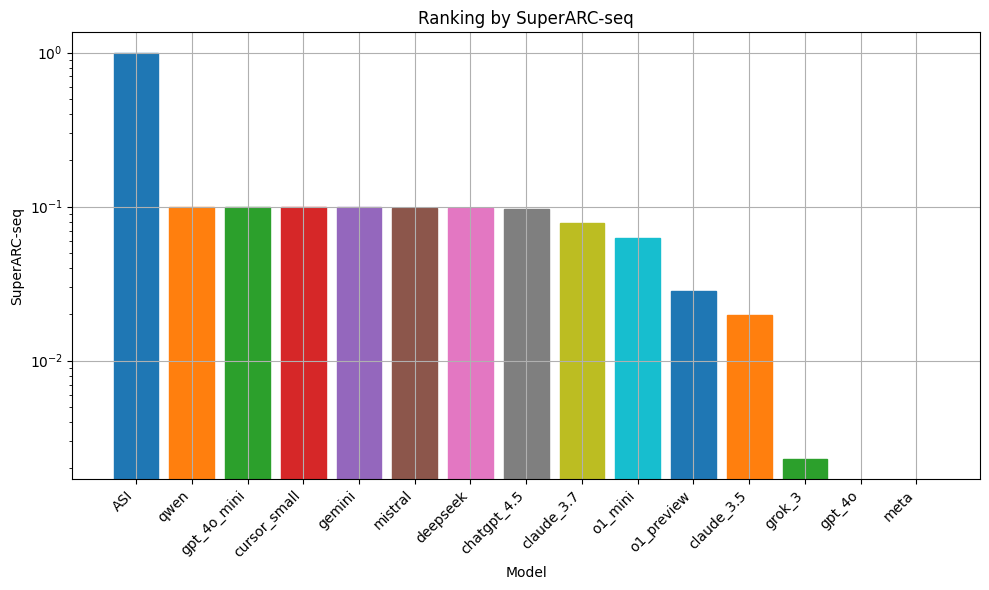

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# Sort values in descending order
sorted_df = df_ranking2.sort_values('tst', ascending=False)
# Create bar plot using Model column with default color cycle
bars = plt.bar(range(len(sorted_df)), sorted_df['tst'])
# Set different colors for each bar using default color cycle
for i, bar in enumerate(bars):
    bar.set_color(f'C{i}')
plt.grid(True)
plt.title('Ranking by SuperARC-seq')
plt.xlabel('Model')
plt.ylabel('SuperARC-seq')
# Set y-axis to log scale
plt.yscale('log')
# Set x-tick labels with model names
plt.xticks(range(len(sorted_df)), sorted_df['Model'], rotation=45, ha='right')
plt.tight_layout()
plt.show()


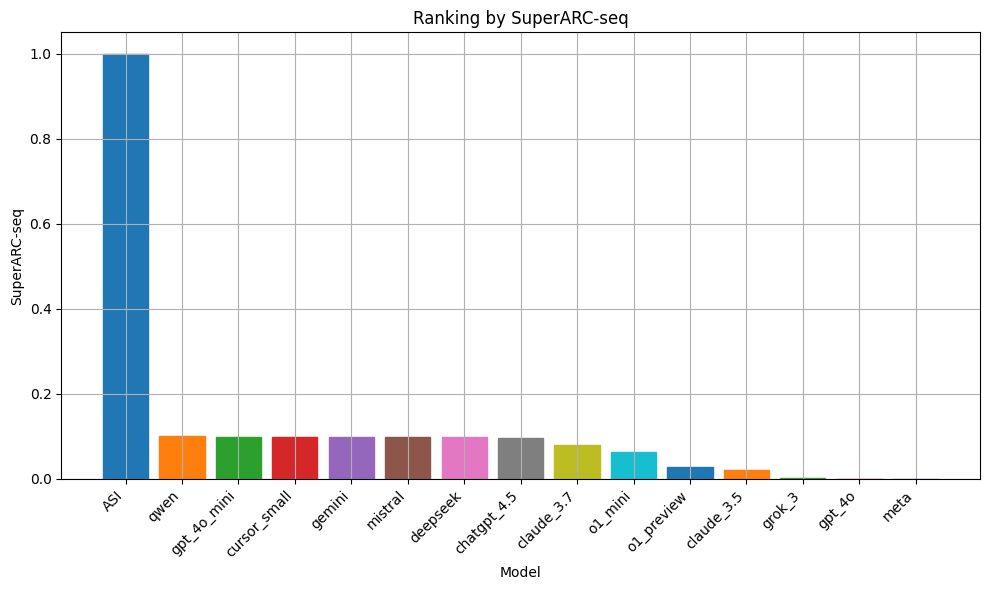

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# Sort values in descending order
sorted_df = df_ranking2.sort_values('tst', ascending=False)
# Create bar plot using Model column with default color cycle
bars = plt.bar(range(len(sorted_df)), sorted_df['tst'])
# Set different colors for each bar using default color cycle
for i, bar in enumerate(bars):
    bar.set_color(f'C{i}')
plt.grid(True)
plt.title('Ranking by SuperARC-seq')
plt.xlabel('Model')
plt.ylabel('SuperARC-seq')

# Set x-tick labels with model names
plt.xticks(range(len(sorted_df)), sorted_df['Model'], rotation=45, ha='right')
plt.tight_layout()
plt.show()